Guardado: /data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/mapa_poblacion_sao_francisco.png

Total 2015: 24,398,722  |  Total 2030: 19,846,338  |  Diferencia: -18.7%


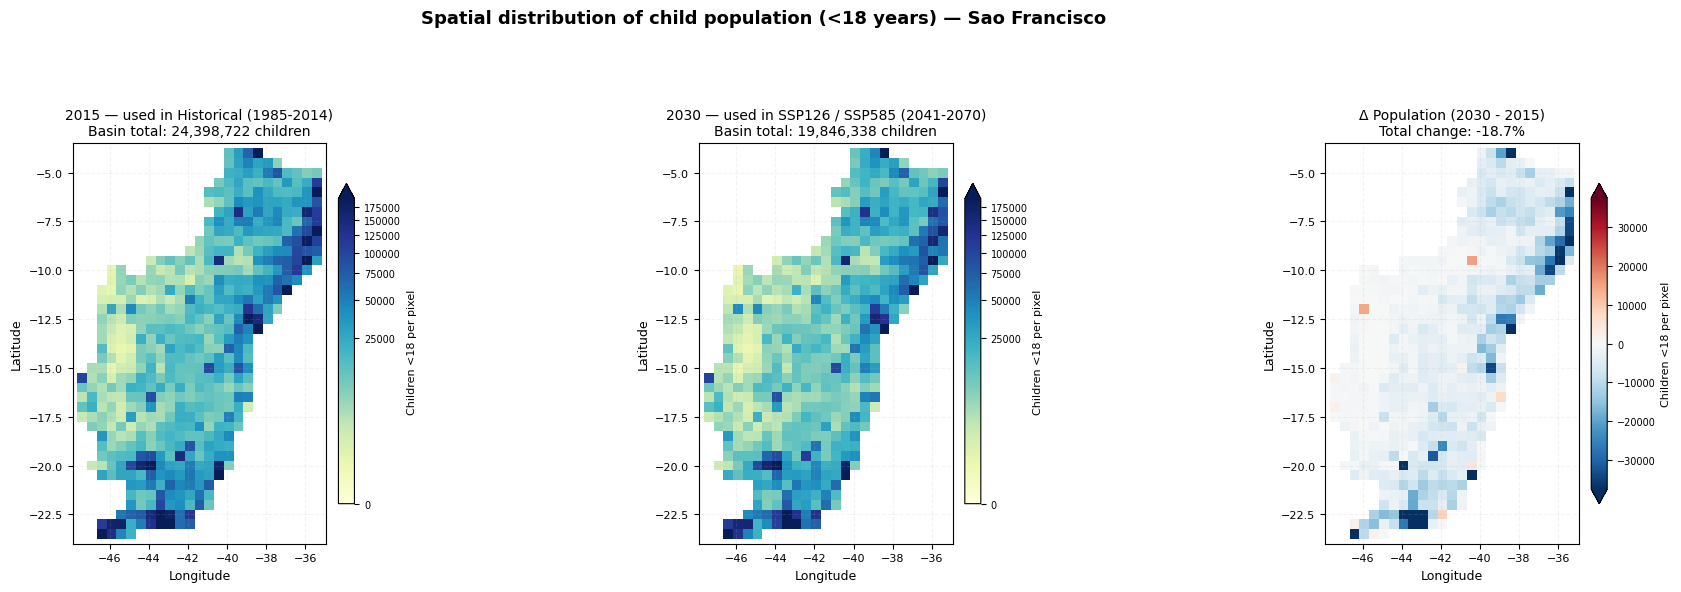

In [13]:
"""
MAPA DE POBLACION — Sao Francisco.

Muestra la distribucion espacial pura de poblacion infantil (<18 años),
SIN mezclar con sequia. Es un mapa fijo por periodo (no varia por año dentro
del periodo), ya que la metodologia usa poblacion estatica.

Dos paneles: WorldPop 2015 (usado en historical) y WorldPop 2030 (usado en
ssp126/ssp585), con la MISMA escala de color entre ambos, para poder comparar
directamente si la distribucion espacial de poblacion cambio entre 2015 y 2030
(no solo el total, que ya sabemos que baja: 31.2M -> 25.7M).

Requiere: xarray, numpy, matplotlib
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------

BASIN = "sao_francisco"
POP_DIR = "/data/brussel/vo/000/bvo00033/vsc11346/Exposure/5.Population_regridded/"
DROUGHT_NC_REF = "/data/brussel/vo/000/bvo00033/vsc11346/SPEI_R/7.Caracterizacion_sequia/SPEI-12/2.General_anual/2.Outputs/Sao_Francisco/historical/drought_annual_sao_francisco_historical_ensemble.nc"

POP_NC = {
    "2015": f"{POP_DIR}worldpop_under18_2015_{BASIN}.nc",
    "2030": f"{POP_DIR}worldpop_under18_2030_{BASIN}.nc",
}

CMAP = "YlGnBu"  # paleta distinta a sequia/exposicion (que usan YlOrRd), para diferenciar visualmente el tipo de mapa
GAMMA = 0.3

# ------------------------------------------------------------------
# CARGA
# ------------------------------------------------------------------

ds = {y: xr.open_dataset(p) for y, p in POP_NC.items()}
lat = ds["2015"]["lat"].values
lon = ds["2015"]["lon"].values

data_2015 = ds["2015"]["population_under18"].values
data_2030 = ds["2030"]["population_under18"].values

# ------------------------------------------------------------------
# MASCARA REAL DE LA CUENCA (desde el archivo de sequia, que SI tiene la
# forma irregular correcta -- la poblacion regrideada solo esta recortada
# al rectangulo delimitador, no a la forma real de la cuenca)
# ------------------------------------------------------------------

ds_drought = xr.open_dataset(DROUGHT_NC_REF)
# valido si tiene dato en AL MENOS UN año (la mascara deberia ser constante en el tiempo,
# pero usamos .any() por seguridad)
basin_mask = ds_drought["frequency"].notnull().any(dim="year").values
ds_drought.close()

data_2015 = np.where(basin_mask, data_2015, np.nan)
data_2030 = np.where(basin_mask, data_2030, np.nan)

total_2015 = float(np.nansum(data_2015))
total_2030 = float(np.nansum(data_2030))

delta = data_2030 - data_2015

# escala de color COMPARTIDA entre 2015 y 2030 (percentil 98 combinado, PowerNorm)
combined = np.concatenate([data_2015[~np.isnan(data_2015)], data_2030[~np.isnan(data_2030)]])
vmax = float(np.nanpercentile(combined, 98))
norm = mcolors.PowerNorm(gamma=GAMMA, vmin=0, vmax=vmax)

# escala divergente para el mapa de diferencia (percentil 98 del |delta|)
delta_valid = delta[~np.isnan(delta)]
vmax_delta = float(np.nanpercentile(np.abs(delta_valid), 98))
norm_delta = mcolors.Normalize(vmin=-vmax_delta, vmax=vmax_delta)

# ------------------------------------------------------------------
# RECORTE A LA EXTENSION REAL DE LA CUENCA (no toda la grilla rectangular)
# ------------------------------------------------------------------

valid_any = ~np.isnan(data_2015) | ~np.isnan(data_2030)
rows_valid = np.any(valid_any, axis=1)
cols_valid = np.any(valid_any, axis=0)

lat_valid = lat[rows_valid]
lon_valid = lon[cols_valid]

res_lat = abs(lat[1] - lat[0])
res_lon = abs(lon[1] - lon[0])
pad = 1  # pixeles de margen

lat_min = lat_valid.min() - pad * res_lat
lat_max = lat_valid.max() + pad * res_lat
lon_min = lon_valid.min() - pad * res_lon
lon_max = lon_valid.max() + pad * res_lon

# ------------------------------------------------------------------
# FIGURA
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle(
    f"Spatial distribution of child population (<18 years) — {BASIN.replace('_',' ').title()}\n",
    fontsize=13, fontweight="bold",
)

paneles = [
    (data_2015, "2015 — used in Historical (1985-2014)", f"Basin total: {total_2015:,.0f} children", CMAP, norm, "max"),
    (data_2030, "2030 — used in SSP126 / SSP585 (2041-2070)", f"Basin total: {total_2030:,.0f} children", CMAP, norm, "max"),
    (delta, "Δ Population (2030 - 2015)", f"Total change: {100*(total_2030-total_2015)/total_2015:+.1f}%", "RdBu_r", norm_delta, "both"),
]

for ax, (data, title, subtitle, cmap, nrm, extend) in zip(axes, paneles):
    data_masked = np.ma.masked_invalid(data)
    mesh = ax.pcolormesh(lon, lat, data_masked, cmap=cmap, norm=nrm, shading="auto")
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.15, linestyle="--")
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.8, pad=0.02, extend=extend)
    cbar.set_label("Children <18 per pixel", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
print(f"Guardado: {OUT_PNG}")
print(f"\nTotal 2015: {total_2015:,.0f}  |  Total 2030: {total_2030:,.0f}  |  Diferencia: {100*(total_2030-total_2015)/total_2015:.1f}%")
plt.show()

Guardado: /data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/mapa_absoluto_compartido_exposure_frequency_sao_francisco.png


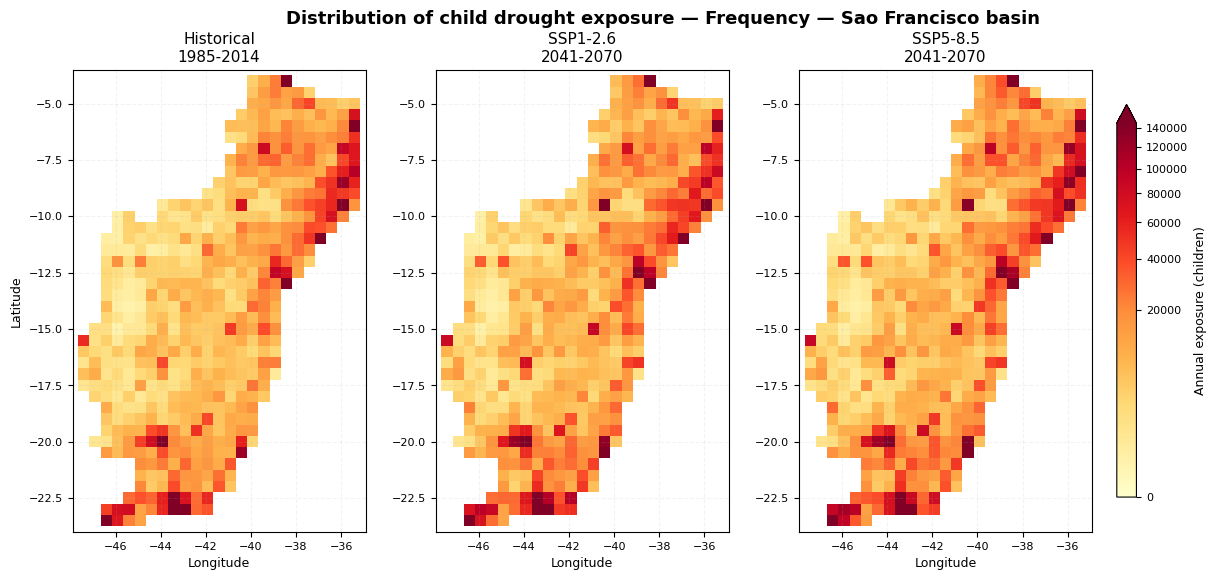

Guardado: /data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/mapa_absoluto_compartido_exposure_duration_sao_francisco.png


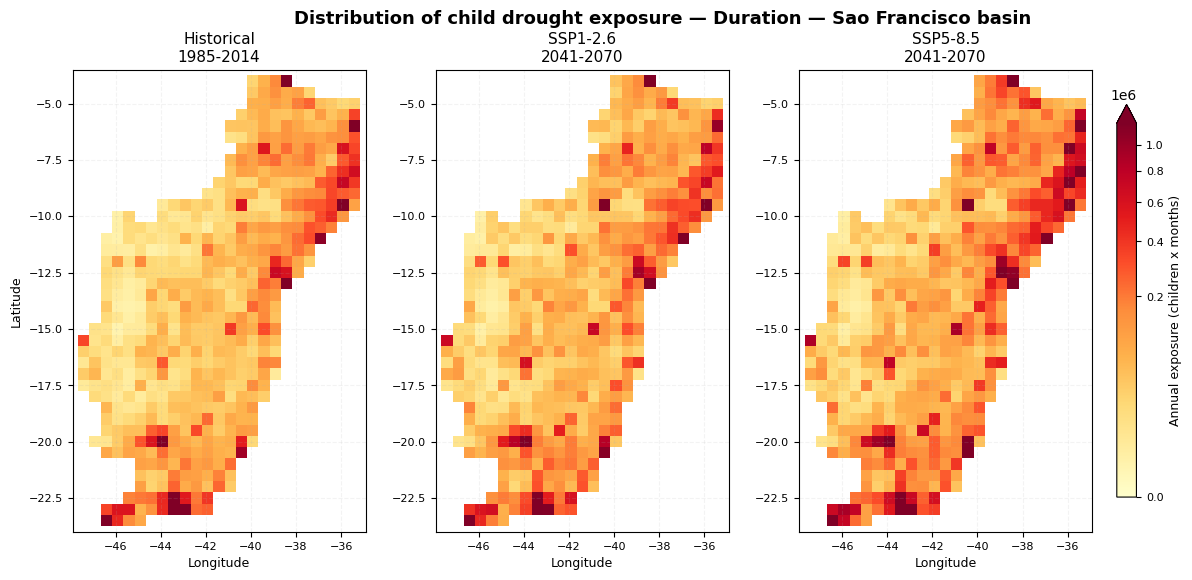

Guardado: /data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/mapa_absoluto_compartido_exposure_severity_sao_francisco.png


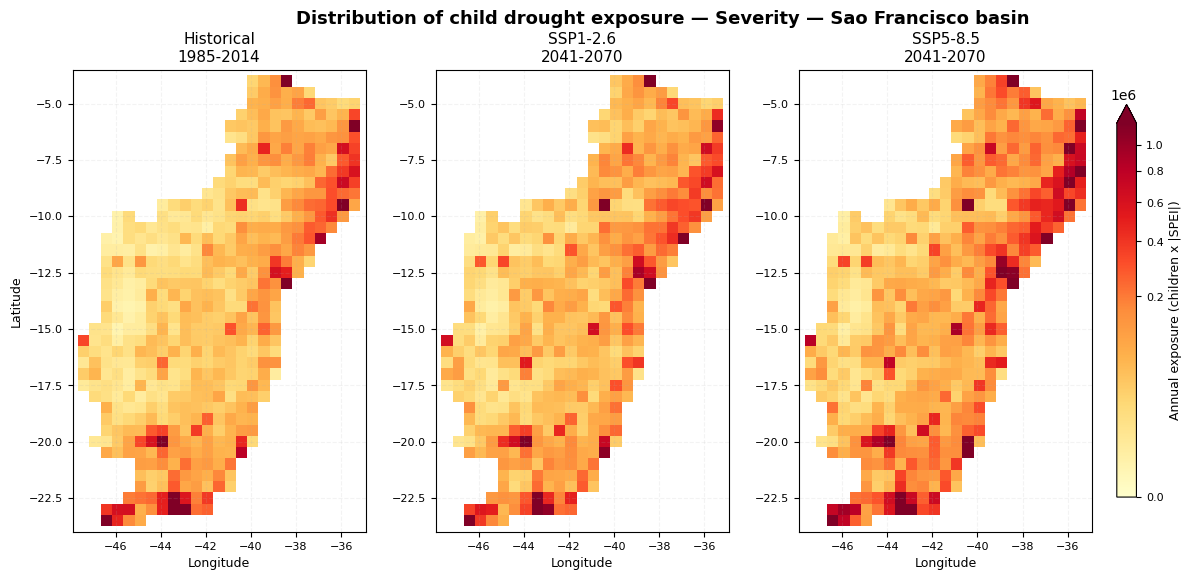

In [14]:
"""
MAPAS DE EXPOSICION ABSOLUTA CON ESCALA COMPARTIDA — Sao Francisco.

Replica el estilo de la Fig. 7 de tu referencia: 3 paneles lado a lado
(Historical / SSP126 / SSP585), CADA UNO CON LA MISMA ESCALA DE COLOR
(compartida entre los 3), para que el cambio de intensidad entre escenarios
se vea directamente por color, sin tener que comparar numeros.

Diferencia clave con la version anterior (mapas_comparativos_exposicion):
  - Ahi cada mapa tenia su propia escala (percentil 98 de SU PROPIO dato) ->
    por eso no se notaba el cambio entre escenarios a simple vista.
  - Aca la escala se calcula UNA vez, combinando los 3 escenarios juntos,
    y se aplica igual a los 3 paneles.

Se genera UNA figura por variable (frequency, duration, severity), porque
cada variable tiene una escala de magnitud muy distinta y no tendria sentido
compartir el color entre ellas.

Escala de color CONTINUA (no clasificada en bins discretos, a pedido).

Requiere: xarray, numpy, matplotlib
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------

BASIN = "sao_francisco"

EXPOSURE_NC = {
    "historical": f"{OUT_DIR}exposure_annual_{BASIN}_historical_ensemble.nc",
    "ssp126":     f"{OUT_DIR}exposure_annual_{BASIN}_ssp126_ensemble.nc",
    "ssp585":     f"{OUT_DIR}exposure_annual_{BASIN}_ssp585_ensemble.nc",
}

VARS = [
    ("exposure_frequency", "Frequency", "children"),
    ("exposure_duration",  "Duration",  "children x months"),
    ("exposure_severity",  "Severity",  "children x |SPEI|"),
]

PANELES = [
    ("historical", "Historical\n1985-2014"),
    ("ssp126",     "SSP1-2.6\n2041-2070"),
    ("ssp585",     "SSP5-8.5\n2041-2070"),
]

CMAP = "YlOrRd"
GAMMA = 0.35  # compresion de escala (poblacion sesgada por pixeles urbanos)


# ------------------------------------------------------------------
# CARGA Y PROMEDIOS POR PIXEL
# ------------------------------------------------------------------

ds = {sc: xr.open_dataset(path) for sc, path in EXPOSURE_NC.items()}
lat = ds["historical"]["lat"].values
lon = ds["historical"]["lon"].values

avg = {sc: {var: dset[var].mean(dim="year", skipna=True).values for var, _, _ in VARS} for sc, dset in ds.items()}

# ------------------------------------------------------------------
# RECORTE A LA EXTENSION REAL DE LA CUENCA
# ------------------------------------------------------------------

valid_any = np.zeros(avg["historical"][VARS[0][0]].shape, dtype=bool)
for sc in avg:
    for var, _, _ in VARS:
        valid_any |= ~np.isnan(avg[sc][var])

rows_valid = np.any(valid_any, axis=1)
cols_valid = np.any(valid_any, axis=0)
lat_valid = lat[rows_valid]
lon_valid = lon[cols_valid]
res_lat = abs(lat[1] - lat[0])
res_lon = abs(lon[1] - lon[0])
pad = 1
lat_min, lat_max = lat_valid.min() - pad*res_lat, lat_valid.max() + pad*res_lat
lon_min, lon_max = lon_valid.min() - pad*res_lon, lon_valid.max() + pad*res_lon


# ------------------------------------------------------------------
# UNA FIGURA POR VARIABLE
# ------------------------------------------------------------------

for var, var_label, unit in VARS:

    # escala COMPARTIDA entre los 3 escenarios (percentil 98 combinado)
    combined = np.concatenate([avg[sc][var][~np.isnan(avg[sc][var])] for sc, _ in PANELES])
    vmax = float(np.nanpercentile(combined, 98))
    norm = mcolors.PowerNorm(gamma=GAMMA, vmin=0, vmax=vmax)

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(
        f"Distribution of child drought exposure — {var_label} — {BASIN.replace('_',' ').title()} basin",
        fontsize=13, fontweight="bold",
    )

    for ax, (sc, sc_label) in zip(axes, PANELES):
        data = np.ma.masked_invalid(avg[sc][var])
        mesh = ax.pcolormesh(lon, lat, data, cmap=CMAP, norm=norm, shading="auto")
        ax.set_title(sc_label, fontsize=11)
        ax.set_xlabel("Longitude", fontsize=9)
        ax.set_aspect("equal")
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.15, linestyle="--")

    axes[0].set_ylabel("Latitude", fontsize=9)

    # colorbar UNICA, compartida por los 3 paneles
    cbar = fig.colorbar(mesh, ax=axes.tolist(), shrink=0.85, pad=0.02, extend="max", orientation="vertical")
    cbar.set_label(f"Annual exposure ({unit})", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    out_png = f"{OUT_DIR}mapa_absoluto_compartido_{var}_{BASIN}.png"
    print(f"Guardado: {out_png}")
    plt.show()

In [13]:
import pandas as pd
import numpy as np

path_out = "/data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/"

df_hist = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_historical_ensemble.csv")
df_126  = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_ssp126_ensemble.csv")
df_585  = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_ssp585_ensemble.csv")

print("=" * 65)
print("EXPOSURE ANALYSIS — Sao Francisco — SPEI-12")
print("Children under 18 exposed to drought (annual total)")
print("=" * 65)

for name, df in [("Historical (1985-2014)", df_hist),
                 ("SSP126    (2041-2070)",  df_126),
                 ("SSP585    (2041-2070)",  df_585)]:
    print(f"\n{name}:")
    for col in ["exposure_frequency", "exposure_duration", "exposure_severity"]:
        vals = df[col]
        print(f"  {col}:")
        print(f"    Min:    {vals.min()/1e6:>8.2f} M children")
        print(f"    Max:    {vals.max()/1e6:>8.2f} M children")
        print(f"    Mean:   {vals.mean()/1e6:>8.2f} M children/year")
        print(f"    Median: {vals.median()/1e6:>8.2f} M children/year")

# Comparacion entre escenarios
print("\n" + "=" * 65)
print("CHANGE — Mean annual exposure (millions of children)")
print("=" * 65)
print(f"\n{'Metric':<25} {'Historical':>12} {'SSP126':>12} {'SSP585':>12}")
print("-" * 65)

for col, label in [
    ("exposure_frequency", "Frequency exposure"),
    ("exposure_duration",  "Duration exposure"),
    ("exposure_severity",  "Severity exposure")
]:
    h   = df_hist[col].mean() / 1e6
    s126 = df_126[col].mean() / 1e6
    s585 = df_585[col].mean() / 1e6
    print(f"{label:<25} {h:>10.2f}M {s126:>10.2f}M {s585:>10.2f}M")
    print(f"  {'% change SSP126':<23} {'—':>12} {(s126-h)/h*100:>+11.1f}% {'—':>12}")
    print(f"  {'% change SSP585':<23} {'—':>12} {'—':>12} {(s585-h)/h*100:>+11.1f}%")

EXPOSURE ANALYSIS — Sao Francisco — SPEI-12
Children under 18 exposed to drought (annual total)

Historical (1985-2014):
  exposure_frequency:
    Min:        0.00 M children
    Max:       24.10 M children
    Mean:      12.01 M children/year
    Median:    12.52 M children/year
  exposure_duration:
    Min:        0.00 M children
    Max:      262.76 M children
    Mean:      82.79 M children/year
    Median:    78.57 M children/year
  exposure_severity:
    Min:        0.00 M children
    Max:      354.01 M children
    Mean:      80.53 M children/year
    Median:    56.56 M children/year

SSP126    (2041-2070):
  exposure_frequency:
    Min:        2.68 M children
    Max:       19.46 M children
    Mean:      14.11 M children/year
    Median:    15.34 M children/year
  exposure_duration:
    Min:        9.65 M children
    Max:      182.03 M children
    Mean:      96.12 M children/year
    Median:   101.80 M children/year
  exposure_severity:
    Min:        7.39 M children
    M

In [17]:
import numpy as np
import xarray as xr

path_out = "/data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/"

nc_file = f"{path_out}exposure_annual_sao_francisco_historical_ensemble.nc"
ds = xr.open_dataset(nc_file)
print("=== NetCDF HISTORICAL ===")
print(ds)
print("\nVariables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims} → shape {ds[var].shape}")
    data = ds[var].values.astype(float)
    data = np.where(data == -9999, np.nan, data)
    # Suma sobre los 30 años → total acumulado
    total = np.nansum(data, axis=0)
    total = np.where(np.all(np.isnan(data), axis=0), np.nan, total)
    print(f"    Total acumulado 30 años:")
    print(f"    Min:    {np.nanmin(total)/1e6:.2f}M")
    print(f"    Max:    {np.nanmax(total)/1e6:.2f}M")
    print(f"    Median: {np.nanmedian(total)/1e6:.2f}M")
ds.close()

=== NetCDF HISTORICAL ===
<xarray.Dataset> Size: 360kB
Dimensions:             (year: 30, lat: 40, lon: 25)
Coordinates:
  * year                (year) int32 120B 1985 1986 1987 1988 ... 2012 2013 2014
  * lat                 (lat) float32 160B -23.5 -23.0 -22.5 ... -5.0 -4.5 -4.0
  * lon                 (lon) float32 100B -47.42 -46.92 ... -35.92 -35.42
Data variables:
    exposure_frequency  (year, lat, lon) float32 120kB ...
    exposure_duration   (year, lat, lon) float32 120kB ...
    exposure_severity   (year, lat, lon) float32 120kB ...
Attributes:
    description:        Annual child drought exposure — sao_francisco, histor...
    basin:              sao_francisco
    scenario:           historical
    model:              ensemble
    population_source:  WorldPop 2015 (static)

Variables:
  exposure_frequency: ('year', 'lat', 'lon') → shape (30, 40, 25)
    Total acumulado 30 años:
    Min:    0.00M
    Max:    42.71M
    Median: 0.23M
  exposure_duration: ('year', 'lat', 'lon'

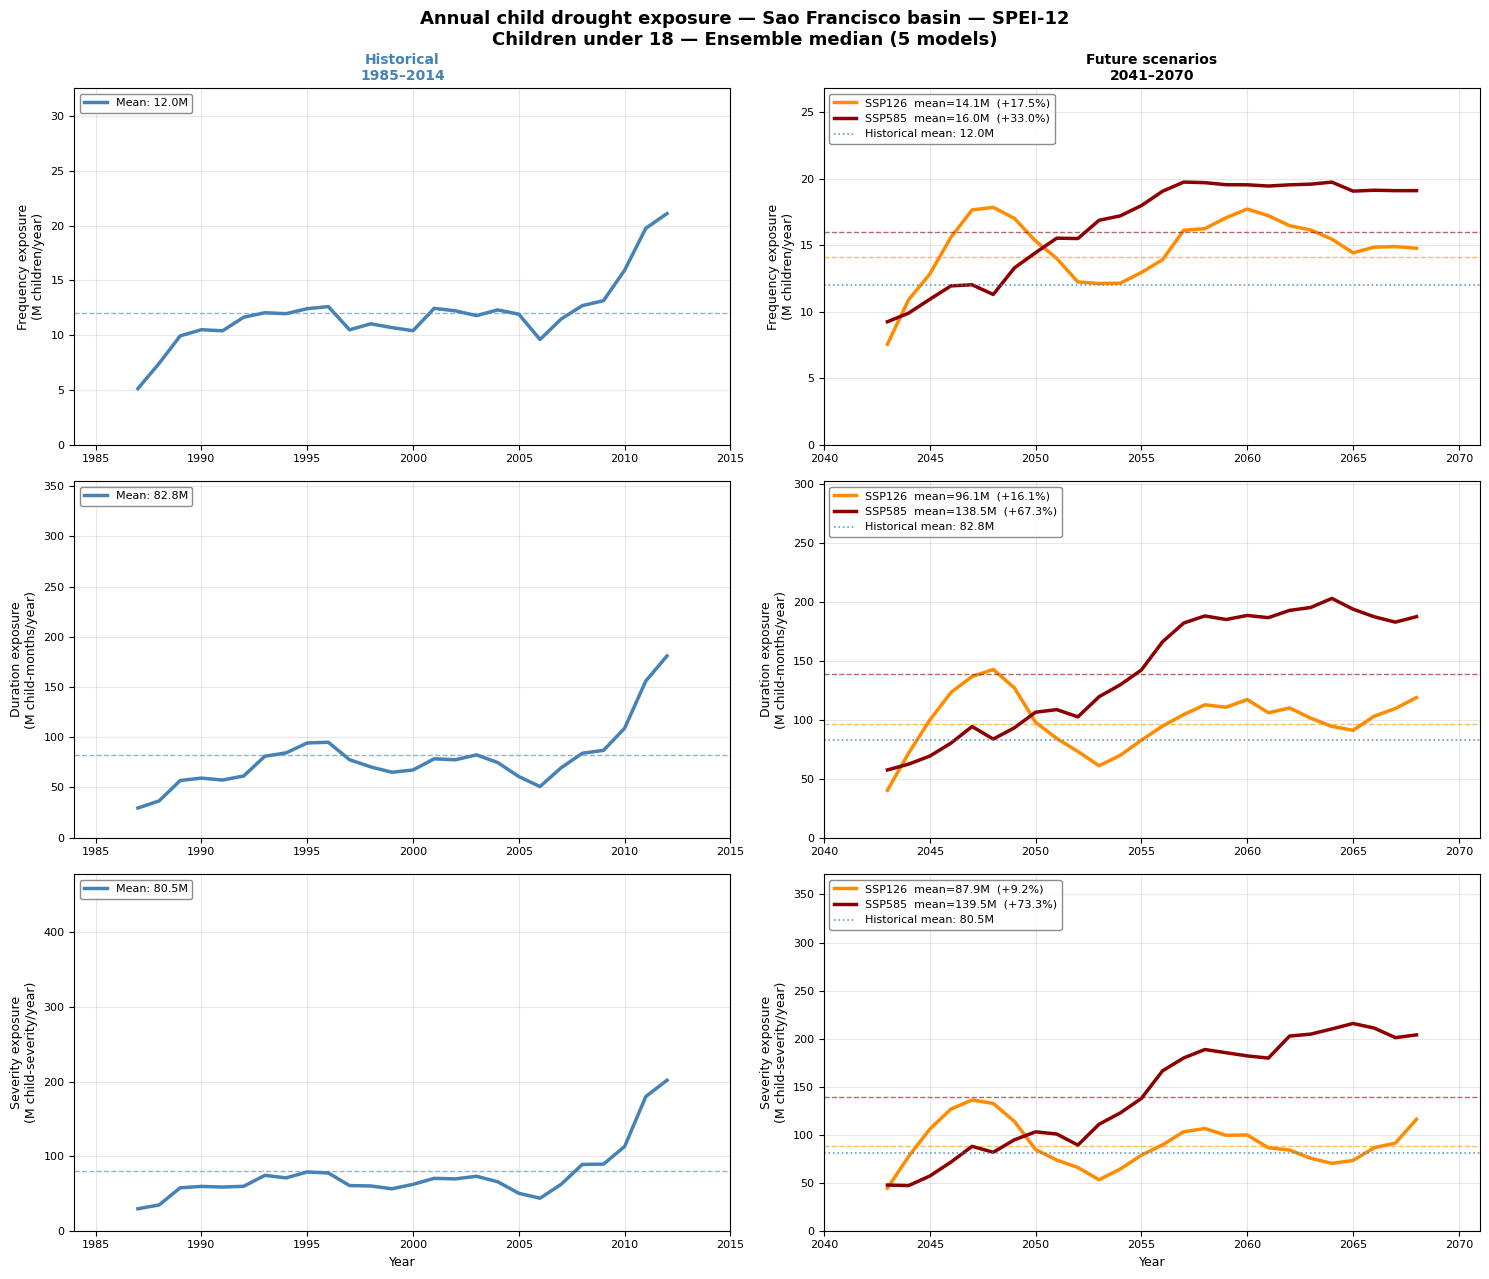

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
path_out = "/data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/"

df_hist = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_historical_ensemble.csv")
df_126  = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_ssp126_ensemble.csv")
df_585  = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_ssp585_ensemble.csv")

for df in [df_hist, df_126, df_585]:
    df["exposure_frequency"] = df["exposure_frequency"] / 1e6
    df["exposure_duration"]  = df["exposure_duration"]  / 1e6
    df["exposure_severity"]  = df["exposure_severity"]  / 1e6

def moving_avg(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='valid')

c_hist = "steelblue"
c_126  = "darkorange"
c_585  = "darkred"

metrics = [
    ("exposure_frequency", "Frequency exposure\n(M children/year)"),
    ("exposure_duration",  "Duration exposure\n(M child-months/year)"),
    ("exposure_severity",  "Severity exposure\n(M child-severity/year)"),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle("Annual child drought exposure — Sao Francisco basin — SPEI-12\n"
             "Children under 18 — Ensemble median (5 models)",
             fontsize=13, fontweight="bold", y=0.98)

for row, (col, ylabel) in enumerate(metrics):

    # --- Columna izquierda: Historical ---
    ax_hist = axes[row, 0]

    years_h = df_hist["year"].values
    vals_h  = df_hist[col].values

    # Solo media movil y media del período
    ax_hist.plot(years_h[2:-2], moving_avg(vals_h), color=c_hist,
                 linewidth=2.5, label=f"Mean: {vals_h.mean():.1f}M")
    ax_hist.axhline(vals_h.mean(), color=c_hist, linewidth=1,
                    linestyle="--", alpha=0.6)

    ymax = vals_h.max() * 1.35
    ax_hist.set_ylim(bottom=0, top=ymax)
    ax_hist.set_xlim(years_h[0] - 1, years_h[-1] + 1)
    ax_hist.set_ylabel(ylabel, fontsize=9)
    ax_hist.tick_params(labelsize=8)
    ax_hist.grid(True, alpha=0.3)
    ax_hist.legend(fontsize=8, loc="upper left",
                   framealpha=0.9, edgecolor="gray")

    if row == 0:
        ax_hist.set_title("Historical\n1985–2014", fontsize=10,
                          fontweight="bold", color=c_hist)
    if row == 2:
        ax_hist.set_xlabel("Year", fontsize=9)

    # --- Columna derecha: SSP126 vs SSP585 ---
    ax_fut = axes[row, 1]

    years_126 = df_126["year"].values
    years_585 = df_585["year"].values
    vals_126  = df_126[col].values
    vals_585  = df_585[col].values

    # SSP126 — solo media movil y media
    ax_fut.plot(years_126[2:-2], moving_avg(vals_126), color=c_126,
                linewidth=2.5,
                label=f"SSP126  mean={vals_126.mean():.1f}M  "
                      f"(+{(vals_126.mean()-vals_h.mean())/vals_h.mean()*100:.1f}%)")
    ax_fut.axhline(vals_126.mean(), color=c_126, linewidth=1,
                   linestyle="--", alpha=0.6)

    # SSP585 — solo media movil y media
    ax_fut.plot(years_585[2:-2], moving_avg(vals_585), color=c_585,
                linewidth=2.5,
                label=f"SSP585  mean={vals_585.mean():.1f}M  "
                      f"(+{(vals_585.mean()-vals_h.mean())/vals_h.mean()*100:.1f}%)")
    ax_fut.axhline(vals_585.mean(), color=c_585, linewidth=1,
                   linestyle="--", alpha=0.6)

    # Línea de referencia histórica
    ax_fut.axhline(vals_h.mean(), color=c_hist, linewidth=1.2,
                   linestyle=":", alpha=0.8,
                   label=f"Historical mean: {vals_h.mean():.1f}M")

    ymax_fut = max(vals_126.max(), vals_585.max()) * 1.35
    ax_fut.set_ylim(bottom=0, top=ymax_fut)
    ax_fut.set_xlim(years_126[0] - 1, years_585[-1] + 1)
    ax_fut.set_ylabel(ylabel, fontsize=9)
    ax_fut.tick_params(labelsize=8)
    ax_fut.grid(True, alpha=0.3)
    ax_fut.legend(fontsize=8, loc="upper left",
                  framealpha=0.9, edgecolor="gray")

    if row == 0:
        ax_fut.set_title("Future scenarios\n2041–2070", fontsize=10,
                         fontweight="bold")
    if row == 2:
        ax_fut.set_xlabel("Year", fontsize=9)

plt.tight_layout()
plt.show()

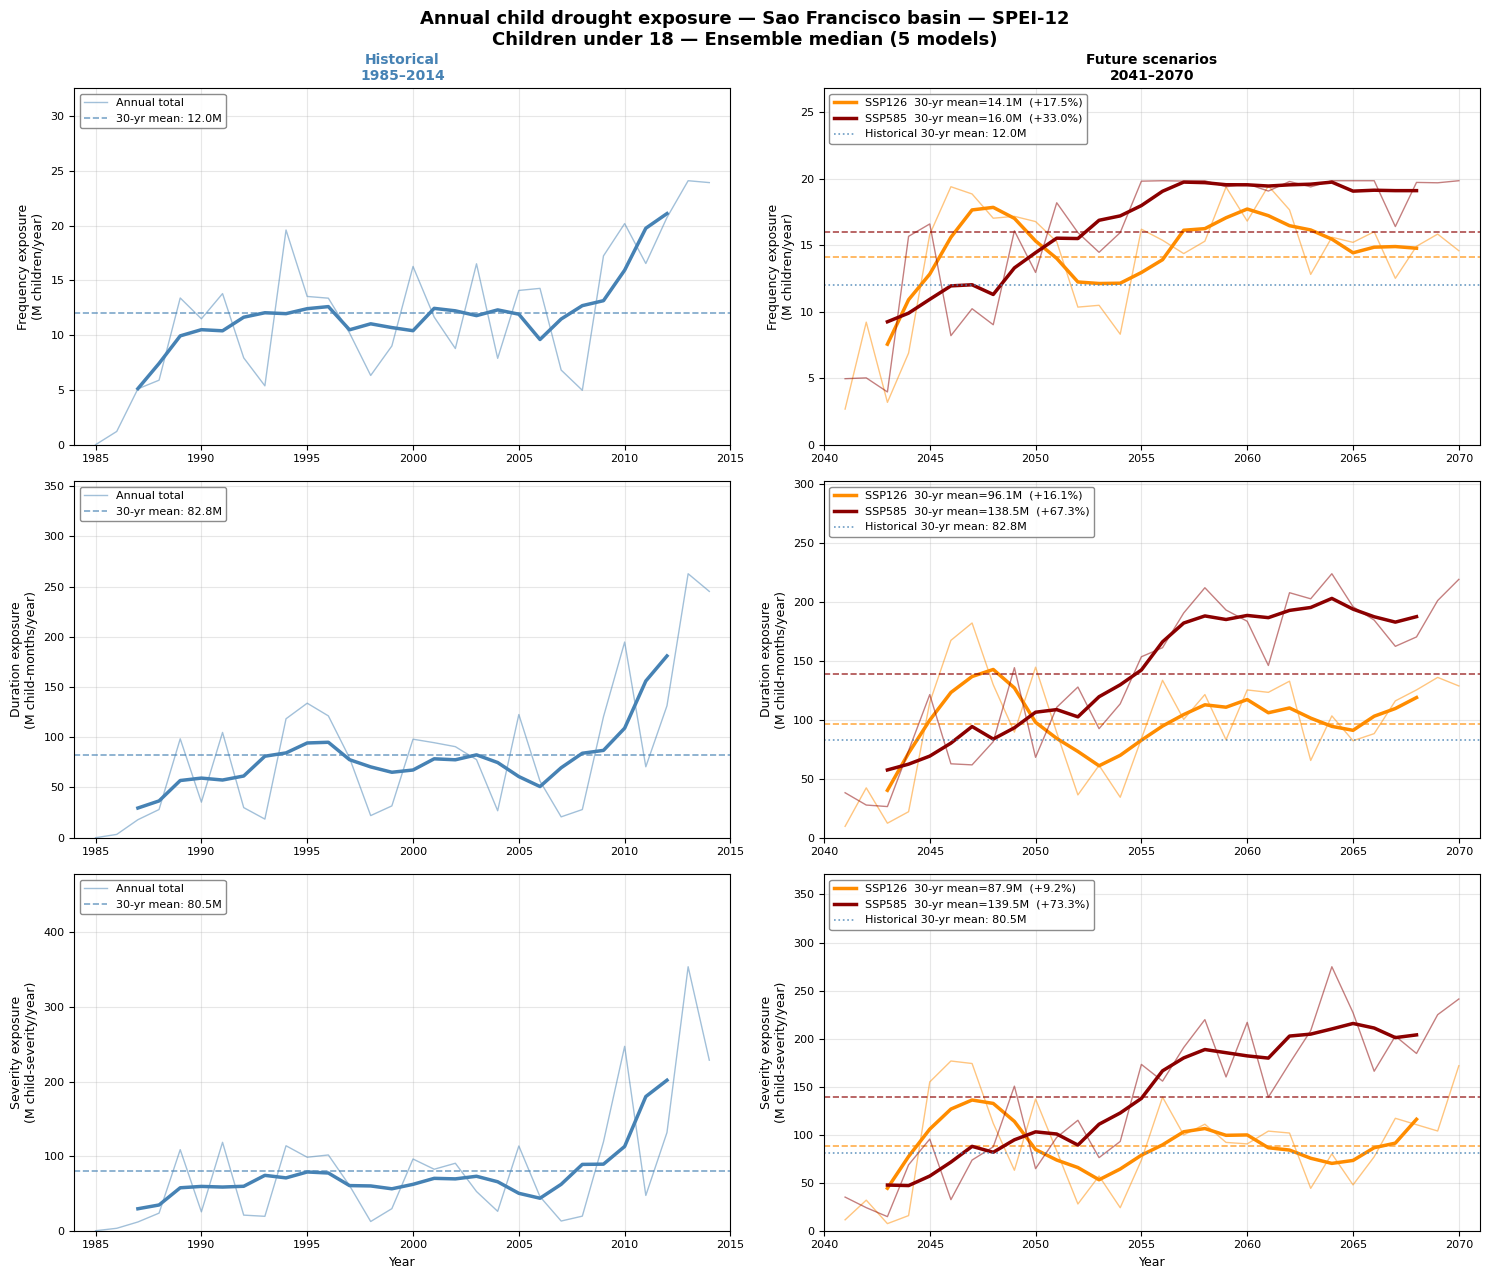

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
path_out = "/data/brussel/vo/000/bvo00033/vsc11346/Exposure/6.Final_outputs/Sao_Francisco/"

df_hist = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_historical_ensemble.csv")
df_126  = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_ssp126_ensemble.csv")
df_585  = pd.read_csv(f"{path_out}resumen_anual_sao_francisco_ssp585_ensemble.csv")

for df in [df_hist, df_126, df_585]:
    df["exposure_frequency"] = df["exposure_frequency"] / 1e6
    df["exposure_duration"]  = df["exposure_duration"]  / 1e6
    df["exposure_severity"]  = df["exposure_severity"]  / 1e6

def moving_avg(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='valid')

c_hist = "steelblue"
c_126  = "darkorange"
c_585  = "darkred"

metrics = [
    ("exposure_frequency", "Frequency exposure\n(M children/year)"),
    ("exposure_duration",  "Duration exposure\n(M child-months/year)"),
    ("exposure_severity",  "Severity exposure\n(M child-severity/year)"),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle("Annual child drought exposure — Sao Francisco basin — SPEI-12\n"
             "Children under 18 — Ensemble median (5 models)",
             fontsize=13, fontweight="bold", y=0.98)

for row, (col, ylabel) in enumerate(metrics):

    # --- Columna izquierda: Historical ---
    ax_hist = axes[row, 0]

    years_h = df_hist["year"].values
    vals_h  = df_hist[col].values

    # Línea anual
    ax_hist.plot(years_h, vals_h, color=c_hist,
                 linewidth=1.0, alpha=0.5, label="Annual total")

    # Media móvil 5 años
    ax_hist.plot(years_h[2:-2], moving_avg(vals_h), color=c_hist,
                 linewidth=2.5)

    # Media del período
    ax_hist.axhline(vals_h.mean(), color=c_hist, linewidth=1.2,
                    linestyle="--", alpha=0.7,
                    label=f"30-yr mean: {vals_h.mean():.1f}M")

    ymax = vals_h.max() * 1.35
    ax_hist.set_ylim(bottom=0, top=ymax)
    ax_hist.set_xlim(years_h[0] - 1, years_h[-1] + 1)
    ax_hist.set_ylabel(ylabel, fontsize=9)
    ax_hist.tick_params(labelsize=8)
    ax_hist.grid(True, alpha=0.3)
    ax_hist.legend(fontsize=8, loc="upper left",
                   framealpha=0.9, edgecolor="gray")

    if row == 0:
        ax_hist.set_title("Historical\n1985–2014", fontsize=10,
                          fontweight="bold", color=c_hist)
    if row == 2:
        ax_hist.set_xlabel("Year", fontsize=9)

    # --- Columna derecha: SSP126 vs SSP585 ---
    ax_fut = axes[row, 1]

    years_126 = df_126["year"].values
    years_585 = df_585["year"].values
    vals_126  = df_126[col].values
    vals_585  = df_585[col].values

    # SSP126 — línea anual + media móvil
    ax_fut.plot(years_126, vals_126, color=c_126,
                linewidth=1.0, alpha=0.5)
    ax_fut.plot(years_126[2:-2], moving_avg(vals_126), color=c_126,
                linewidth=2.5,
                label=f"SSP126  30-yr mean={vals_126.mean():.1f}M  "
                      f"(+{(vals_126.mean()-vals_h.mean())/vals_h.mean()*100:.1f}%)")
    ax_fut.axhline(vals_126.mean(), color=c_126, linewidth=1.2,
                   linestyle="--", alpha=0.7)

    # SSP585 — línea anual + media móvil
    ax_fut.plot(years_585, vals_585, color=c_585,
                linewidth=1.0, alpha=0.5)
    ax_fut.plot(years_585[2:-2], moving_avg(vals_585), color=c_585,
                linewidth=2.5,
                label=f"SSP585  30-yr mean={vals_585.mean():.1f}M  "
                      f"(+{(vals_585.mean()-vals_h.mean())/vals_h.mean()*100:.1f}%)")
    ax_fut.axhline(vals_585.mean(), color=c_585, linewidth=1.2,
                   linestyle="--", alpha=0.7)

    # Línea de referencia histórica
    ax_fut.axhline(vals_h.mean(), color=c_hist, linewidth=1.2,
                   linestyle=":", alpha=0.8,
                   label=f"Historical 30-yr mean: {vals_h.mean():.1f}M")

    ymax_fut = max(vals_126.max(), vals_585.max()) * 1.35
    ax_fut.set_ylim(bottom=0, top=ymax_fut)
    ax_fut.set_xlim(years_126[0] - 1, years_585[-1] + 1)
    ax_fut.set_ylabel(ylabel, fontsize=9)
    ax_fut.tick_params(labelsize=8)
    ax_fut.grid(True, alpha=0.3)
    ax_fut.legend(fontsize=8, loc="upper left",
                  framealpha=0.9, edgecolor="gray")

    if row == 0:
        ax_fut.set_title("Future scenarios\n2041–2070", fontsize=10,
                         fontweight="bold")
    if row == 2:
        ax_fut.set_xlabel("Year", fontsize=9)

plt.tight_layout()
plt.show()